# Tech Challenge Fase 1 — NPS Preditivo
**Objetivo:** Explorar dados operacionais de um e-commerce para entender os fatores que influenciam o NPS dos clientes e propor um modelo preditivo.

---

## 1. Setup e Carregamento dos Dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

# Carregamento
df = pd.read_csv('../data/desafio_nps_fase_1.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (2500, 19)


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


## 2. Entendimento Inicial dos Dados

In [2]:
# Tipos e valores nulos
print('=== TIPOS DE DADOS ===')
print(df.dtypes)
print()
print('=== VALORES NULOS ===')
print(df.isnull().sum())

=== TIPOS DE DADOS ===
customer_id                    int64
customer_age                   int64
customer_region                  str
customer_tenure_months         int64
order_id                       int64
order_value                  float64
items_quantity                 int64
discount_value               float64
payment_installments           int64
delivery_time_days             int64
delivery_delay_days            int64
freight_value                float64
delivery_attempts              int64
customer_service_contacts      int64
resolution_time_days           int64
nps_score                    float64
repeat_purchase_30d            int64
complaints_count               int64
csat_internal_score          float64
dtype: object

=== VALORES NULOS ===
customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value      

In [3]:
# Estatísticas descritivas
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
customer_id,2500.0,1250.50,721.83,1.00,625.75,1250.50,1875.25,2500.00
customer_age,2500.0,43.40,14.89,18.00,31.00,43.00,56.00,69.00
customer_tenure_months,2500.0,61.32,34.48,1.00,31.00,62.00,91.00,119.00
order_id,2500.0,51250.50,721.83,50001.00,50625.75,51250.50,51875.25,52500.00
order_value,2500.0,434.26,289.77,7.76,220.24,375.52,577.29,1983.81
items_quantity,2500.0,3.47,1.69,1.00,2.00,3.00,5.00,6.00
discount_value,2500.0,29.75,29.23,0.02,8.88,20.94,40.83,230.33
payment_installments,2500.0,6.00,3.16,1.00,3.00,6.00,9.00,11.00
delivery_time_days,2500.0,8.02,3.77,2.00,5.00,8.00,11.00,14.00
delivery_delay_days,2500.0,2.19,1.45,0.00,1.00,2.00,3.00,8.00


## 3. Definição da Variável Target e Segmentação NPS

A variável **`nps_score`** (0–10) é a target do problema. Seguindo a metodologia NPS:
- **Promotores:** nota 9 ou 10
- **Neutros:** nota 7 ou 8
- **Detratores:** nota 0 a 6

In [4]:
# Criar coluna de segmento NPS
def classificar_nps(score):
    if score >= 9:
        return 'Promotor'
    elif score >= 7:
        return 'Neutro'
    else:
        return 'Detrator'

df['nps_segment'] = df['nps_score'].apply(classificar_nps)

# Distribuição
contagem = df['nps_segment'].value_counts()
pct = df['nps_segment'].value_counts(normalize=True) * 100
resumo = pd.DataFrame({'Quantidade': contagem, 'Percentual (%)': pct.round(1)})
print(resumo)

# NPS calculado
pct_promotores = (df['nps_segment'] == 'Promotor').mean() * 100
pct_detratores = (df['nps_segment'] == 'Detrator').mean() * 100
nps_empresa = round(pct_promotores - pct_detratores, 1)
print(f'\nNPS da Empresa: {nps_empresa}')

             Quantidade  Percentual (%)
nps_segment                            
Detrator           2109            84.4
Neutro              281            11.2
Promotor            110             4.4

NPS da Empresa: -80.0


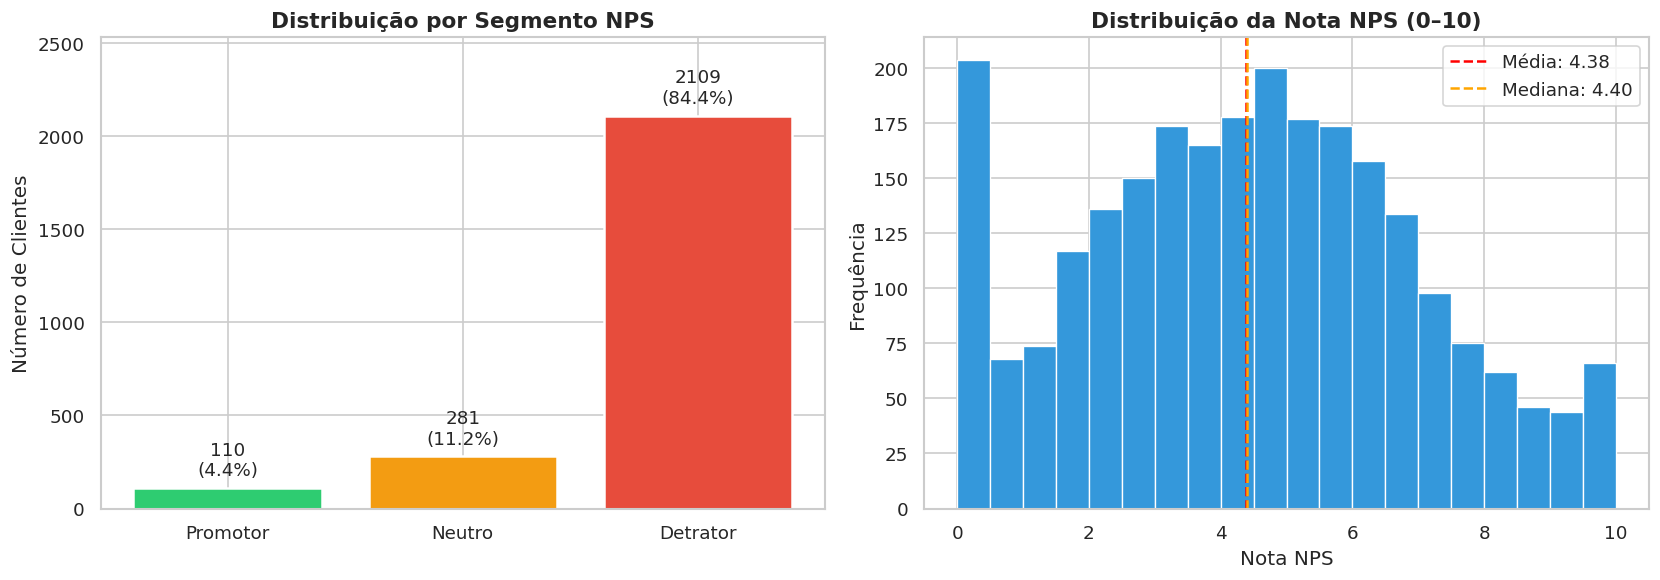

In [5]:
# Gráfico de distribuição NPS
cores = {'Promotor': '#2ecc71', 'Neutro': '#f39c12', 'Detrator': '#e74c3c'}
ordem = ['Promotor', 'Neutro', 'Detrator']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras de segmento
ax = axes[0]
vals = [contagem[s] for s in ordem]
bars = ax.bar(ordem, vals, color=[cores[s] for s in ordem], edgecolor='white', linewidth=1.5)
ax.bar_label(bars, labels=[f'{v}\n({pct[s]:.1f}%)' for s, v in zip(ordem, vals)], padding=5, fontsize=11)
ax.set_title('Distribuição por Segmento NPS', fontsize=13, fontweight='bold')
ax.set_ylabel('Número de Clientes')
ax.set_ylim(0, max(vals) * 1.2)

# Histograma do score
ax2 = axes[1]
ax2.hist(df['nps_score'], bins=20, color='#3498db', edgecolor='white', linewidth=0.8)
ax2.axvline(df['nps_score'].mean(), color='red', linestyle='--', label=f'Média: {df["nps_score"].mean():.2f}')
ax2.axvline(df['nps_score'].median(), color='orange', linestyle='--', label=f'Mediana: {df["nps_score"].median():.2f}')
ax2.set_title('Distribuição da Nota NPS (0–10)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Nota NPS')
ax2.set_ylabel('Frequência')
ax2.legend()

plt.tight_layout()
plt.savefig('../reports/01_distribuicao_nps.png', bbox_inches='tight')
plt.show()

## 4. Análise Exploratória (EDA)
### 4.1 Fatores Logísticos

                NPS Médio  Qtd Clientes
faixa_atraso                           
Sem atraso           6.86           277
Até 2 dias           5.05          1261
3–5 dias             2.89           911
Mais de 5 dias       0.81            51


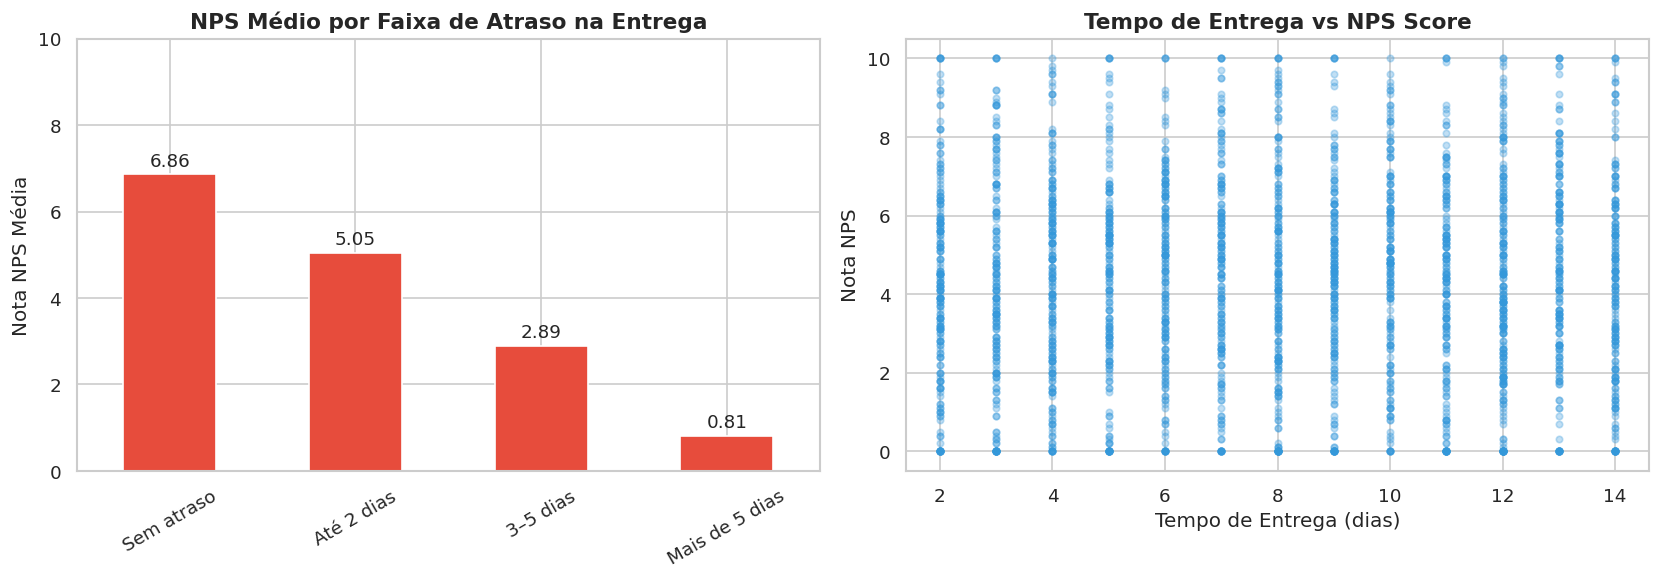

In [6]:
# NPS médio por faixa de atraso na entrega
bins_atraso = [-1, 0, 2, 5, 100]
labels_atraso = ['Sem atraso', 'Até 2 dias', '3–5 dias', 'Mais de 5 dias']
df['faixa_atraso'] = pd.cut(df['delivery_delay_days'], bins=bins_atraso, labels=labels_atraso)

resumo_atraso = df.groupby('faixa_atraso')['nps_score'].agg(['mean', 'count']).round(2)
resumo_atraso.columns = ['NPS Médio', 'Qtd Clientes']
print(resumo_atraso)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# NPS médio por atraso
resumo_atraso['NPS Médio'].plot(kind='bar', ax=axes[0], color='#e74c3c', edgecolor='white')
axes[0].set_title('NPS Médio por Faixa de Atraso na Entrega', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nota NPS Média')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylim(0, 10)
for i, v in enumerate(resumo_atraso['NPS Médio']):
    axes[0].text(i, v + 0.2, f'{v:.2f}', ha='center', fontsize=11)

# Scatter: tempo de entrega x NPS
axes[1].scatter(df['delivery_time_days'], df['nps_score'], alpha=0.3, color='#3498db', s=15)
axes[1].set_title('Tempo de Entrega vs NPS Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tempo de Entrega (dias)')
axes[1].set_ylabel('Nota NPS')

plt.tight_layout()
plt.savefig('../reports/02_logistica_nps.png', bbox_inches='tight')
plt.show()

### 4.2 Fatores de Atendimento

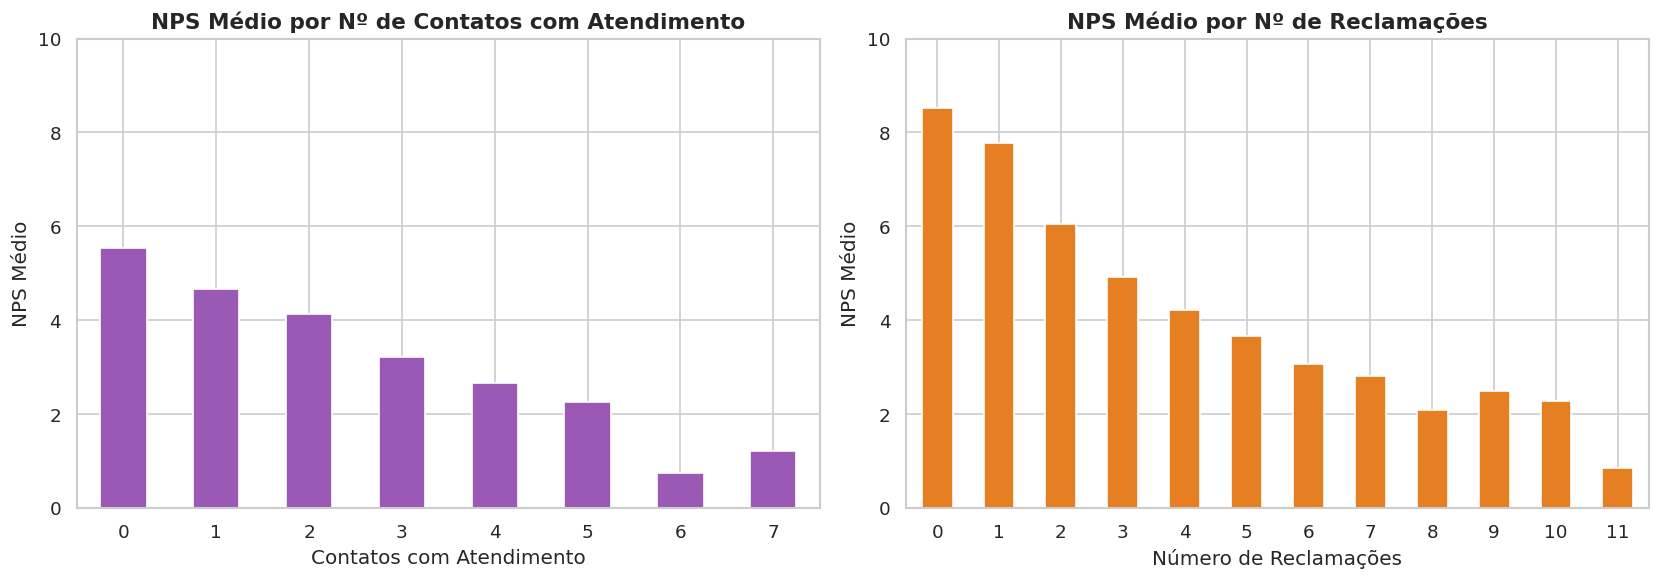

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# NPS médio por número de contatos com atendimento
contatos_nps = df.groupby('customer_service_contacts')['nps_score'].mean().round(2)
contatos_nps.plot(kind='bar', ax=axes[0], color='#9b59b6', edgecolor='white')
axes[0].set_title('NPS Médio por Nº de Contatos com Atendimento', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Contatos com Atendimento')
axes[0].set_ylabel('NPS Médio')
axes[0].set_ylim(0, 10)
axes[0].tick_params(axis='x', rotation=0)

# NPS médio por nº de reclamações
reclam_nps = df.groupby('complaints_count')['nps_score'].mean().round(2)
reclam_nps.plot(kind='bar', ax=axes[1], color='#e67e22', edgecolor='white')
axes[1].set_title('NPS Médio por Nº de Reclamações', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Número de Reclamações')
axes[1].set_ylabel('NPS Médio')
axes[1].set_ylim(0, 10)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../reports/03_atendimento_nps.png', bbox_inches='tight')
plt.show()

### 4.3 Regiões e Perfil do Cliente

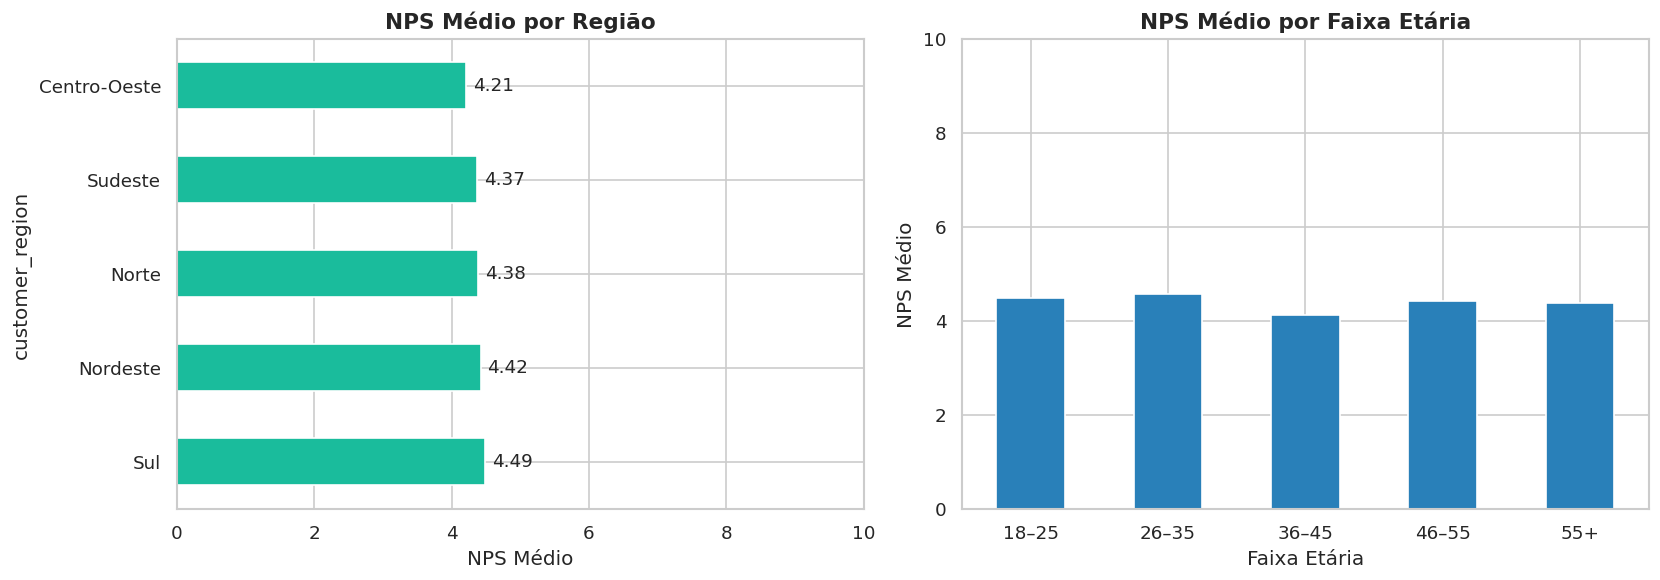

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# NPS por região
regiao_nps = df.groupby('customer_region')['nps_score'].mean().sort_values(ascending=False).round(2)
regiao_nps.plot(kind='barh', ax=axes[0], color='#1abc9c', edgecolor='white')
axes[0].set_title('NPS Médio por Região', fontsize=13, fontweight='bold')
axes[0].set_xlabel('NPS Médio')
axes[0].set_xlim(0, 10)
for i, v in enumerate(regiao_nps):
    axes[0].text(v + 0.1, i, f'{v:.2f}', va='center', fontsize=11)

# NPS por faixa etária
df['faixa_etaria'] = pd.cut(df['customer_age'], bins=[0, 25, 35, 45, 55, 100],
                            labels=['18–25', '26–35', '36–45', '46–55', '55+'])
idade_nps = df.groupby('faixa_etaria')['nps_score'].mean().round(2)
idade_nps.plot(kind='bar', ax=axes[1], color='#2980b9', edgecolor='white')
axes[1].set_title('NPS Médio por Faixa Etária', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Faixa Etária')
axes[1].set_ylabel('NPS Médio')
axes[1].set_ylim(0, 10)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../reports/04_regiao_perfil_nps.png', bbox_inches='tight')
plt.show()

### 4.4 Correlação entre Variáveis Numéricas e o NPS

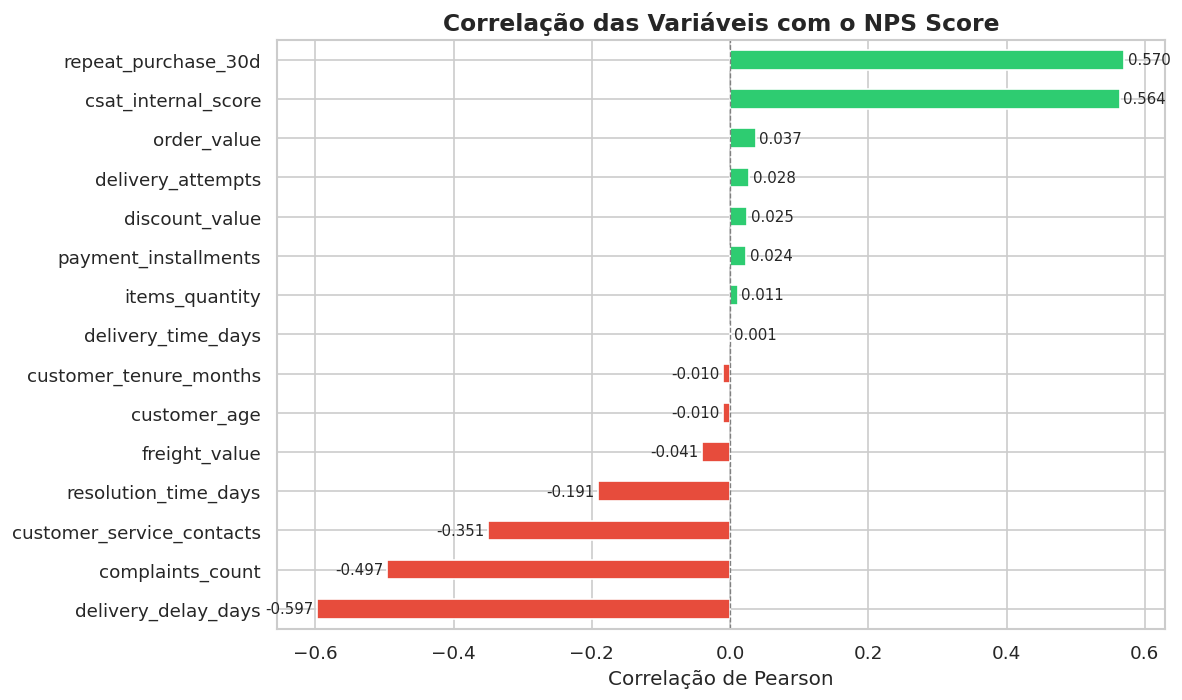


Top 5 correlações negativas (piores para o NPS):
delivery_delay_days         -0.597
complaints_count            -0.497
customer_service_contacts   -0.351
resolution_time_days        -0.191
freight_value               -0.041
Name: nps_score, dtype: float64

Top 5 correlações positivas (melhores para o NPS):
discount_value         0.025
delivery_attempts      0.028
order_value            0.037
csat_internal_score    0.564
repeat_purchase_30d    0.570
Name: nps_score, dtype: float64


In [9]:
# Correlação com nps_score
numericas = df.select_dtypes(include='number').drop(columns=['customer_id', 'order_id'])
corr_nps = numericas.corr()['nps_score'].drop('nps_score').sort_values()

cores_corr = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_nps]

fig, ax = plt.subplots(figsize=(10, 6))
corr_nps.plot(kind='barh', ax=ax, color=cores_corr, edgecolor='white')
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title('Correlação das Variáveis com o NPS Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlação de Pearson')
for i, v in enumerate(corr_nps):
    ax.text(v + (0.005 if v >= 0 else -0.005), i, f'{v:.3f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/05_correlacao_nps.png', bbox_inches='tight')
plt.show()

print('\nTop 5 correlações negativas (piores para o NPS):')
print(corr_nps.head(5).round(3))
print('\nTop 5 correlações positivas (melhores para o NPS):')
print(corr_nps.tail(5).round(3))

### 4.5 Ponto de Ruptura: quando a experiência quebra?

In [10]:
# Comparar detratores vs promotores nas variáveis-chave
comparativo = df[df['nps_segment'].isin(['Promotor', 'Detrator'])].groupby('nps_segment')[[
    'delivery_delay_days', 'customer_service_contacts', 'complaints_count',
    'resolution_time_days', 'delivery_attempts', 'csat_internal_score'
]].mean().round(2).T

comparativo.columns.name = None
comparativo['Diferença (Detrator - Promotor)'] = comparativo['Detrator'] - comparativo['Promotor']
print('Promotores vs Detratores — Médias das Variáveis-Chave')
print(comparativo)

Promotores vs Detratores — Médias das Variáveis-Chave
                           Detrator  Promotor  Diferença (Detrator - Promotor)
delivery_delay_days            2.41      0.72                             1.69
customer_service_contacts      1.63      0.67                             0.96
complaints_count               4.44      2.27                             2.17
resolution_time_days           5.69      3.70                             1.99
delivery_attempts              2.00      2.15                            -0.15
csat_internal_score            2.54      6.04                            -3.50


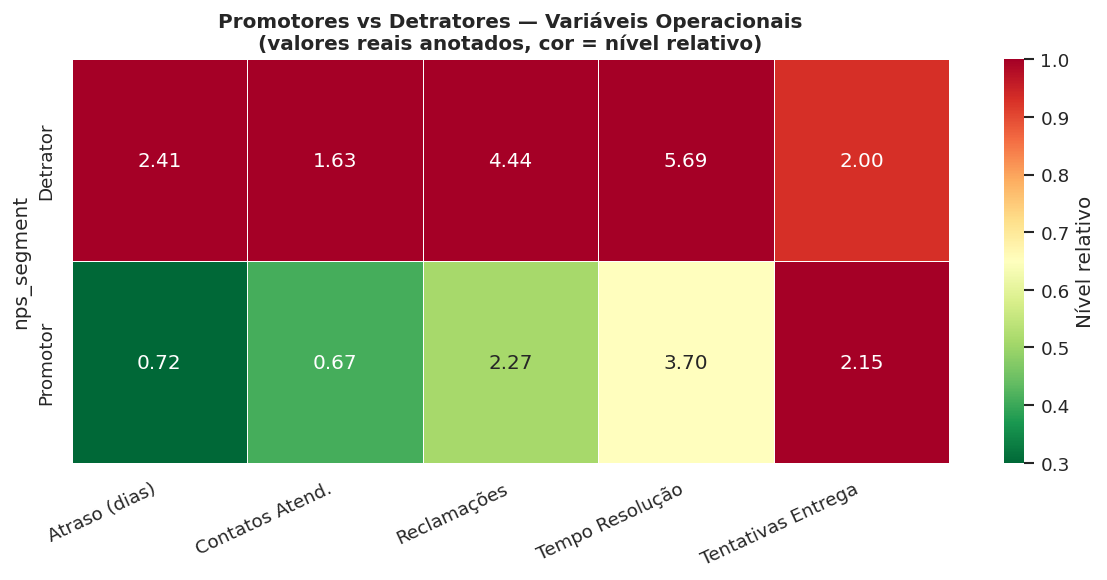

In [11]:
# Heatmap comparativo
fig, ax = plt.subplots(figsize=(10, 5))
dados_heat = df[df['nps_segment'].isin(['Promotor', 'Detrator'])].groupby('nps_segment')[[
    'delivery_delay_days', 'customer_service_contacts', 'complaints_count',
    'resolution_time_days', 'delivery_attempts'
]].mean().round(2)

# Normalizar por coluna para visualização
dados_norm = dados_heat.div(dados_heat.max())
sns.heatmap(dados_norm, annot=dados_heat.values, fmt='.2f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Nível relativo'})
ax.set_title('Promotores vs Detratores — Variáveis Operacionais\n(valores reais anotados, cor = nível relativo)', 
             fontsize=12, fontweight='bold')
ax.set_xticklabels([
    'Atraso (dias)', 'Contatos Atend.', 'Reclamações',
    'Tempo Resolução', 'Tentativas Entrega'
], rotation=25, ha='right')

plt.tight_layout()
plt.savefig('../reports/06_heatmap_promotor_detrator.png', bbox_inches='tight')
plt.show()

## 5. Modelo Preditivo (Desafio Opcional)

**Estratégia escolhida:** Classificação binária — **Satisfeito** (NPS ≥ 7) vs **Insatisfeito** (NPS < 7).

**Justificativa de negócio:** A empresa precisa identificar clientes em risco *antes* de colher o NPS. Uma classificação binária é mais acionável: permite disparar réguas de retenção para quem tem alta probabilidade de ser detrator/neutro.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

# --- Definição da target binária ---
# Satisfeito: NPS >= 7 (promotores + neutros) | Insatisfeito: NPS < 7 (detratores)
df['target'] = (df['nps_score'] >= 7).astype(int)
print('Distribuição da target:')
print(df['target'].value_counts(normalize=True).round(3) * 100)

Distribuição da target:
target
0    84.4
1    15.6
Name: proportion, dtype: float64


In [13]:
# --- Seleção e preparação das features ---
features = [
    'customer_age', 'customer_tenure_months', 'order_value', 'items_quantity',
    'discount_value', 'payment_installments', 'delivery_time_days',
    'delivery_delay_days', 'freight_value', 'delivery_attempts',
    'customer_service_contacts', 'resolution_time_days',
    'complaints_count', 'repeat_purchase_30d', 'csat_internal_score',
    'customer_region'
]

X = df[features].copy()
y = df['target']

# Encoding da variável categórica
le = LabelEncoder()
X['customer_region'] = le.fit_transform(X['customer_region'])

# Tratar nulos (se houver)
X = X.fillna(X.median())

# --- Split treino/teste (80/20, estratificado) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')

# Normalização
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

Treino: 2000 amostras | Teste: 500 amostras


In [14]:
# --- Treinamento dos modelos ---
modelos = {
    'Regressão Logística': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42)
}

resultados = {}
for nome, modelo in modelos.items():
    X_tr = X_train_sc if nome == 'Regressão Logística' else X_train
    X_te = X_test_sc if nome == 'Regressão Logística' else X_test
    modelo.fit(X_tr, y_train)
    y_pred = modelo.predict(X_te)
    y_proba = modelo.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    resultados[nome] = {'modelo': modelo, 'y_pred': y_pred, 'y_proba': y_proba, 'auc': auc}
    print(f'\n=== {nome} ===')
    print(f'AUC-ROC: {auc:.4f}')
    print(classification_report(y_test, y_pred, target_names=['Insatisfeito', 'Satisfeito']))


=== Regressão Logística ===
AUC-ROC: 0.9190
              precision    recall  f1-score   support

Insatisfeito       0.92      1.00      0.96       422
  Satisfeito       0.95      0.54      0.69        78

    accuracy                           0.92       500
   macro avg       0.94      0.77      0.82       500
weighted avg       0.93      0.92      0.91       500




=== Random Forest ===
AUC-ROC: 0.9167
              precision    recall  f1-score   support

Insatisfeito       0.92      1.00      0.96       422
  Satisfeito       1.00      0.50      0.67        78

    accuracy                           0.92       500
   macro avg       0.96      0.75      0.81       500
weighted avg       0.93      0.92      0.91       500




=== Gradient Boosting ===
AUC-ROC: 0.9193
              precision    recall  f1-score   support

Insatisfeito       0.93      0.99      0.96       422
  Satisfeito       0.94      0.58      0.71        78

    accuracy                           0.93       500
   macro avg       0.93      0.78      0.84       500
weighted avg       0.93      0.93      0.92       500



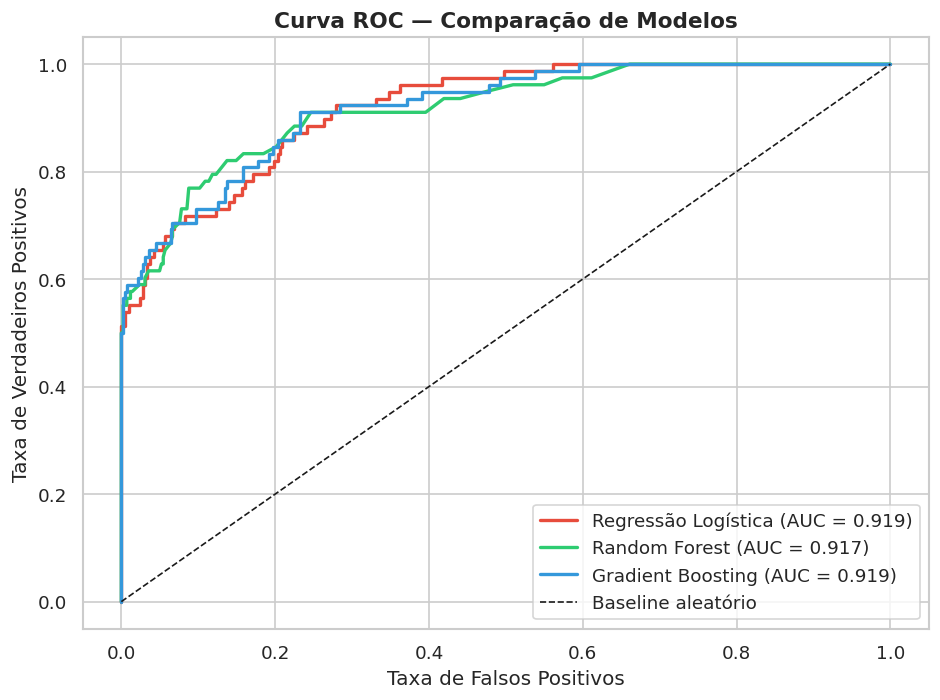

In [15]:
# --- Curvas ROC ---
fig, ax = plt.subplots(figsize=(8, 6))
cores_modelos = ['#e74c3c', '#2ecc71', '#3498db']

for (nome, res), cor in zip(resultados.items(), cores_modelos):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, label=f"{nome} (AUC = {res['auc']:.3f})", color=cor, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Baseline aleatório')
ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.set_title('Curva ROC — Comparação de Modelos', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/07_curva_roc.png', bbox_inches='tight')
plt.show()

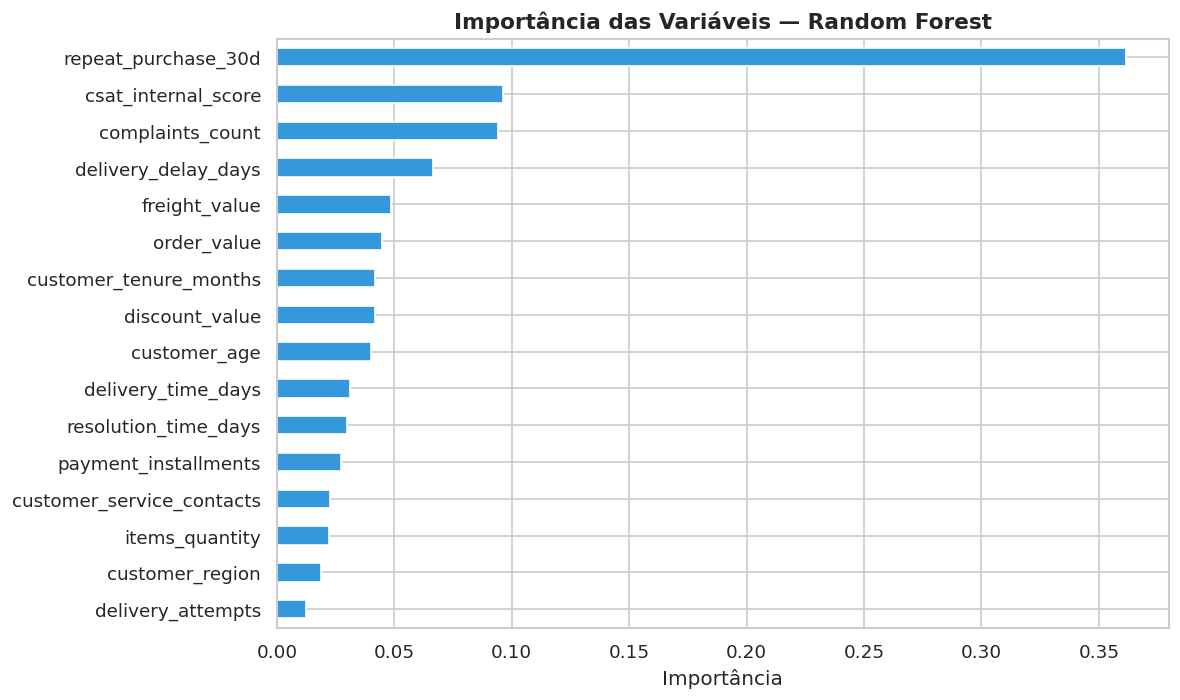


Top 5 variáveis mais importantes:
freight_value          0.0486
delivery_delay_days    0.0663
complaints_count       0.0941
csat_internal_score    0.0961
repeat_purchase_30d    0.3617
dtype: float64


In [16]:
# --- Feature Importance do melhor modelo (Random Forest) ---
rf = resultados['Random Forest']['modelo']
importancias = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
importancias.plot(kind='barh', ax=ax, color='#3498db', edgecolor='white')
ax.set_title('Importância das Variáveis — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importância')
plt.tight_layout()
plt.savefig('../reports/08_feature_importance.png', bbox_inches='tight')
plt.show()

print('\nTop 5 variáveis mais importantes:')
print(importancias.tail(5).round(4))

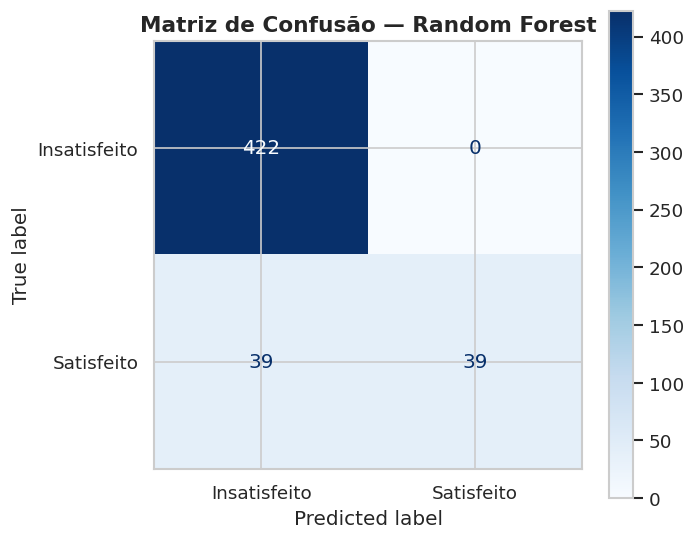

In [17]:
# --- Matriz de Confusão do melhor modelo ---
melhor = 'Random Forest'
X_te = X_test  # RF não usa scaled

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, resultados[melhor]['y_pred'],
    display_labels=['Insatisfeito', 'Satisfeito'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Matriz de Confusão — {melhor}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/09_matriz_confusao.png', bbox_inches='tight')
plt.show()

## 6. Conclusões e Recomendações de Negócio

### Principais achados:
1. **Atraso na entrega** é o fator com maior impacto negativo no NPS — clientes com atraso acima de 5 dias têm nota significativamente menor.
2. **Volume de reclamações e contatos com atendimento** — cada contato adicional reduz a satisfação, sinalizando falhas no primeiro atendimento.
3. **Tempo de resolução** longo é um dos maiores gatilhos de detração.
4. O **csat_internal_score** tem alta correlação positiva com o NPS, indicando que o score interno é um bom proxy para antecipação.

### Recomendações:
- Priorizar SLA de entrega como KPI principal da operação logística.
- Implementar régua de comunicação proativa quando houver risco de atraso.
- Utilizar o modelo preditivo para acionar time de CS em clientes com alta probabilidade de detração **antes** da pesquisa de NPS.
- Monitorar clientes com 2+ reclamações para intervenção proativa.